In [18]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")



True

In [19]:
import os

from pyiceberg.catalog import load_catalog
from pyiceberg.schema import Schema
from pyiceberg.types import LongType, StringType, DoubleType

catalog = load_catalog(
    "default",
    **{
        "type": "rest",
        "uri": os.environ["ICEBERG_REST_URI"],
        "s3.endpoint": os.environ["ICEBERG_S3_ENDPOINT_PUBLIC"],
        "s3.access-key-id": os.environ["ICEBERG_S3_ACCESS_KEY_ID"],
        "s3.secret-access-key": os.environ["ICEBERG_S3_SECRET_ACCESS_KEY"],
    },
)


In [20]:
catalog.list_tables('ukb')

[('ukb', 'hypertension_cohort'), ('ukb', 'olink_instance_0')]

In [21]:
hypertension_cohort = catalog.load_table("ukb.hypertension_cohort")
olink_cohort = catalog.load_table("ukb.olink_instance_0")

In [22]:
import os
os.environ["AWS_ACCESS_KEY_ID"] = os.environ["ICEBERG_S3_ACCESS_KEY_ID"]
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ["ICEBERG_S3_SECRET_ACCESS_KEY"]
os.environ["AWS_ENDPOINT_URL"] = os.environ["ICEBERG_S3_ENDPOINT_PUBLIC"]
os.environ["AWS_REGION"] = os.environ["ICEBERG_S3_REGION"]
os.environ["AWS_ALLOW_HTTP"] = "true"

import polars as pl

In [23]:
hp_df = pl.scan_iceberg(hypertension_cohort)
olink_df = pl.scan_iceberg(olink_cohort)

In [32]:
hp_df.head(5).collect()


participant.eid,participant.p131286,participant.p31,participant.p21003_i0,participant.p21001_i0,participant.p1239_i0,participant.p1249_i0,participant.p20117_i0,participant.p6138_i0,participant.p738_i0,participant.p22189,participant.p54_i0,participant.p4080_i0_a0,participant.p4079_i0_a0,participant.p4080_i0_a1,participant.p4079_i0_a1,participant.p2966_i0,participant.p20161_i0,olink_instance_0.eid
str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,str
"""1000128""","""2003-07-01""",0,62,27.917244,0.0,4.0,2.0,"""[2,3]""",2.0,4.84,11020,127.0,70.0,113.0,74.0,55.0,null,null
"""1000240""",null,0,43,19.838533,1.0,null,0.0,"""[1]""",1.0,1.21,11013,99.0,66.0,93.0,64.0,null,9.275,null
"""1000401""",null,1,56,20.532472,0.0,4.0,2.0,"""[1]""",4.0,1.08,11002,110.0,70.0,108.0,75.0,null,null,null
"""1000477""","""2001-09-01""",0,62,28.425545,0.0,2.0,0.0,"""[3]""",2.0,0.49,11011,138.0,77.0,130.0,78.0,55.0,null,null
"""1000506""",null,0,63,23.662551,0.0,4.0,2.0,"""[3]""",1.0,-2.14,11016,153.0,80.0,135.0,81.0,null,null,null


In [24]:
olink_df.head(5).collect()

eid,a1bg,aamdc,aarsd1,abca2,abhd14b,abl1,abo,abraxas2,acaa1,acadm,acadsb,acan,ace,ace2,ache,acot13,acox1,acp1,acp5,acp6,acrbp,acrv1,acsl1,acta2,actn2,actn4,acvrl1,acy1,acy3,acyp1,ada,ada2,adam12,adam15,adam22,adam23,…,wasl,wdr46,wfdc1,wfdc12,wfdc2,wfikkn1,wfikkn2,wif1,wnt9a,wwp2,xcl1,xg,xiap,xpnpep2,xrcc4,yap1,yars1,yes1,yju2,yod1,ythdf3,ywhaq,yy1,zbp1,zbtb16,zbtb17,zcchc8,zfyve19,zhx2,znf174,znf75d,znf830,znrd2,znrf4,zp3,zp4,zpr1
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1000190,null,null,0.30215,null,null,1.01985,null,null,0.2029,null,null,1.0714,null,0.6189,null,null,1.32895,null,0.74765,0.80215,null,null,null,0.6948,null,0.04235,null,1.09045,null,null,0.03685,-0.16785,null,-0.1713,null,0.35365,…,null,null,null,-0.002,-0.0468,null,0.29605,-0.1376,0.1351,null,-0.4858,0.35065,null,0.14545,0.19865,null,null,1.2325,null,null,1.33885,null,null,null,0.933,0.34205,null,null,null,null,null,null,null,null,null,null,null
1000561,null,null,-0.30405,null,-1.70415,-0.98305,null,null,-0.6176,null,null,0.5892,null,-0.0275,null,null,-0.29895,null,-0.51075,-0.26355,null,null,null,0.239,null,-0.19315,0.1447,-0.75035,null,null,-0.01035,-0.08365,null,0.3496,0.605,0.25215,…,null,null,null,0.7442,0.1054,0.138,0.63895,0.4637,0.2416,-1.4509,-0.1622,0.51705,null,0.35555,-0.39605,null,null,-2.5894,null,null,-2.43985,null,null,null,-1.1629,-0.66235,null,null,null,null,null,null,null,null,null,null,null
1000751,0.0915,-0.54025,-0.22905,0.0727,-0.20995,0.0082,-0.2633,0.2647,-0.11335,-0.0662,0.10195,-0.0527,0.01435,null,0.0013,-0.0037,-0.065,-0.1635,-0.8152,-0.1125,-0.0066,-0.25765,0.3064,null,0.2066,2.87995,0.1181,0.31295,0.4967,-0.5333,-0.315,0.3312,0.6322,null,0.1418,0.5422,…,-0.7692,0.1621,0.4793,0.1092,1.2601,-0.1666,0.2539,0.38725,0.586,-0.0735,0.1188,0.5338,0.0192,0.352,0.0472,0.6145,0.0313,0.5437,0.2001,-0.3961,0.4204,0.0718,0.4433,0.03875,-0.04725,null,-0.3238,0.3745,0.0456,0.216,-0.2987,0.3727,0.19135,-0.0679,0.3216,0.4027,-0.598
1001566,-0.0513,-0.25025,-0.0291,0.19195,-0.5609,-0.0932,0.5822,0.3781,-0.9033,-0.0654,-0.23465,0.1053,0.23085,-0.49075,0.0392,-0.4907,-0.2092,-0.19325,0.1244,0.23,0.1232,-0.45565,0.8866,-0.7563,-0.1294,0.04695,-0.2827,-0.4833,0.3042,-0.3743,-0.1643,0.1629,0.3288,0.16805,0.0146,-0.0082,…,0.1108,0.1205,0.0431,0.4091,0.2216,0.11565,0.3883,0.08145,0.6543,-0.0857,0.2303,0.5478,-0.4298,-1.3687,0.34745,-0.3104,-0.5814,-0.1396,0.0342,-0.2648,-0.34235,-0.3083,0.0485,-0.48155,-0.04605,-0.3924,0.3346,-0.0858,0.0801,-0.1634,-0.1477,1.9119,-0.22735,0.1714,-4.3227,0.1498,0.6211
1002213,0.1618,0.12725,0.00005,-0.3617,0.05145,0.3401,-1.7924,-0.3592,0.5233,-0.3454,0.54525,-0.26905,-0.14175,0.2505,-0.3733,-0.5635,-0.5388,-0.3563,0.2654,-0.4031,0.1682,-0.54585,-0.0932,-0.10195,-0.5712,0.29325,-0.1999,-0.4178,-0.1643,0.2667,0.1374,0.6089,-0.0657,-0.24945,-0.48655,-0.2199,…,-0.2502,0.2585,-0.0612,0.0871,0.2333,-0.9185,-0.3135,0.29085,0.569,0.0898,-0.76745,0.4481,-0.1324,-0.1914,0.22535,0.0262,0.5819,0.3271,-0.1952,0.0595,0.4001,0.0913,-0.7093,-0.35565,0.04115,-0.3758,-0.6546,0.3028,-0.1166,-0.0475,0.0888,-0.224,-0.60155,-0.1991,-4.1014,-0.143,-0.6588


In [25]:
# Use single protein column to join with hypertension
a1bg_df = olink_df.select('eid', 'a1bg')

In [ ]:
# Filter NULL value insides a1bg dataframe
a1bg_nonull_df = a1bg_df.filter(pl.col('a1bg').is_not_null())

In [ ]:
# Convert eid datatype into str
join_df = a1bg_nonull_df.with_columns(pl.col("eid").cast(pl.String)).join(
    hp_df, left_on="eid", right_on="participant.eid", how="inner"
)

In [45]:
join_df.count().collect()

eid,a1bg,participant.p131286,participant.p31,participant.p21003_i0,participant.p21001_i0,participant.p1239_i0,participant.p1249_i0,participant.p20117_i0,participant.p6138_i0,participant.p738_i0,participant.p22189,participant.p54_i0,participant.p4080_i0_a0,participant.p4079_i0_a0,participant.p4080_i0_a1,participant.p4079_i0_a1,participant.p2966_i0,participant.p20161_i0,olink_instance_0.eid
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
44833,44833,19335,44833,44833,44614,44783,41237,44783,44592,44421,44779,44833,42013,42013,41444,41444,12405,13755,44833


In [47]:
# Rename and define varible role
# outcome: p131286 is_null -> without HPT / has_value -> has HPT

hpt_converted_df = join_df.with_columns(pl.col("participant.p131286").is_not_null().alias('hpt')) 

In [52]:
a1bg_hpt_df = hpt_converted_df.select('eid', 'a1bg', 'hpt').collect()

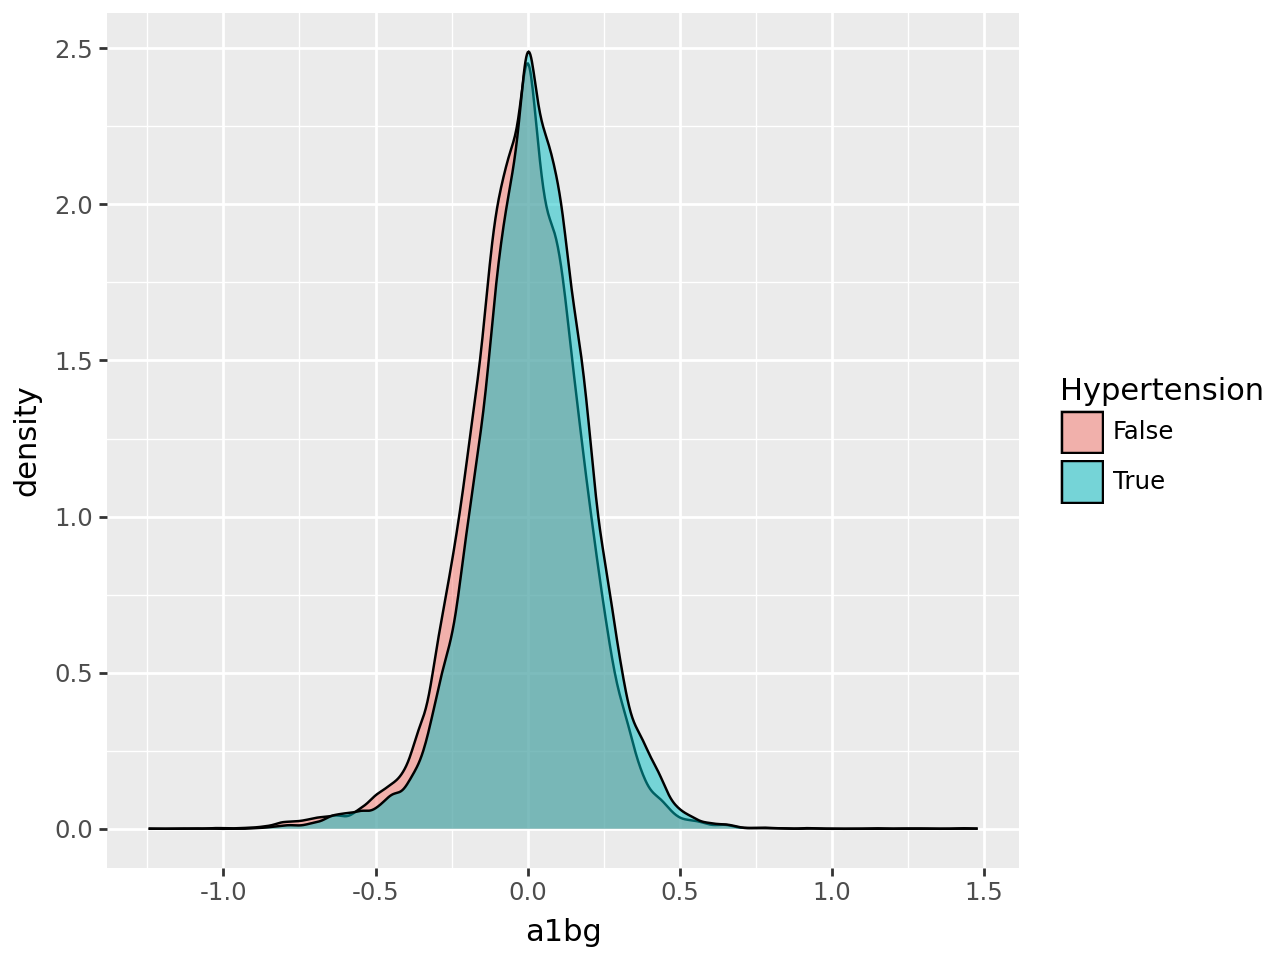

In [81]:
from plotnine import *

(
    ggplot(
        data=a1bg_hpt_df.to_pandas(),
        mapping=aes(x="a1bg", fill="hpt"),
    )
    + geom_density(alpha=0.5)
    # + geom_histogram(mapping=aes(y="..density.."), bins=12, alpha=0.7, position='identity')
    + scale_fill_discrete(name="Hypertension")
)


In [134]:
# Join whole table for sake of convenience
df = (
    olink_df.with_columns(pl.col("eid").cast(pl.String))
    .join(hp_df, left_on="eid", right_on="participant.eid", how="inner")
    .with_columns(pl.col("participant.p131286").is_not_null().alias('hpt'))
)



In [135]:
rename_map = {
    "participant.p131286": "htn_date",
    "participant.p31": "sex",
    "participant.p21003_i0": "age",
    "participant.p21001_i0": "bmi",
    "participant.p1239_i0": "smoking_current",
    "participant.p1249_i0": "smoking_past",
    "participant.p20117_i0": "smoking_pack_years",
    "participant.p6138_i0": "education",
    "participant.p738_i0": "income",
    "participant.p22189": "townsend_di",
    "participant.p54_i0": "assessment_centre",
    "participant.p4080_i0_a0": "systolic_bp_1",
    "participant.p4079_i0_a0": "diastolic_bp_1",
    "participant.p4080_i0_a1": "systolic_bp_2",
    "participant.p4079_i0_a1": "diastolic_bp_2",
    "participant.p2966_i0": "age_htn_diagnosed",
    "olink_instance_0.eid": "olink_eid",
}


df = df.rename(rename_map)

In [136]:
df.head().collect()

eid,a1bg,aamdc,aarsd1,abca2,abhd14b,abl1,abo,abraxas2,acaa1,acadm,acadsb,acan,ace,ace2,ache,acot13,acox1,acp1,acp5,acp6,acrbp,acrv1,acsl1,acta2,actn2,actn4,acvrl1,acy1,acy3,acyp1,ada,ada2,adam12,adam15,adam22,adam23,…,yod1,ythdf3,ywhaq,yy1,zbp1,zbtb16,zbtb17,zcchc8,zfyve19,zhx2,znf174,znf75d,znf830,znrd2,znrf4,zp3,zp4,zpr1,htn_date,sex,age,bmi,smoking_current,smoking_past,smoking_pack_years,education,income,townsend_di,assessment_centre,systolic_bp_1,diastolic_bp_1,systolic_bp_2,diastolic_bp_2,age_htn_diagnosed,participant.p20161_i0,olink_eid,hpt
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,f64,f64,f64,f64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,str,bool
"""1001944""",0.0131,0.46855,0.3114,-0.22135,-0.6701,0.0434,1.8201,0.1543,-0.5558,-0.383,-0.74225,0.1451,-0.46475,0.41485,0.3042,-0.7274,0.0351,0.51965,0.1216,-0.1338,-0.097,1.43755,-0.4366,0.729,-0.2023,0.30645,0.1047,0.3237,-0.2856,-0.0439,-0.1008,-0.2229,-0.3251,0.48715,0.1184,0.0936,…,-0.1391,0.80875,-0.1463,-0.5092,-0.18625,0.15395,-0.1299,0.4416,-0.2593,0.1721,-0.5674,0.7378,2.2855,0.36115,-0.2486,1.3185,-0.062,0.8737,null,1,58,28.15283,0.0,2.0,2.0,"""[1,2,3,6]""",3.0,-4.37,11021,143.0,95.0,140.0,98.0,null,null,"""1001944""",false
"""1002213""",0.1618,0.12725,0.00005,-0.3617,0.05145,0.3401,-1.7924,-0.3592,0.5233,-0.3454,0.54525,-0.26905,-0.14175,0.2505,-0.3733,-0.5635,-0.5388,-0.3563,0.2654,-0.4031,0.1682,-0.54585,-0.0932,-0.10195,-0.5712,0.29325,-0.1999,-0.4178,-0.1643,0.2667,0.1374,0.6089,-0.0657,-0.24945,-0.48655,-0.2199,…,0.0595,0.4001,0.0913,-0.7093,-0.35565,0.04115,-0.3758,-0.6546,0.3028,-0.1166,-0.0475,0.0888,-0.224,-0.60155,-0.1991,-4.1014,-0.143,-0.6588,null,0,63,25.781926,0.0,4.0,0.0,"""[-7]""",1.0,4.37,11021,106.0,75.0,108.0,79.0,-1.0,null,"""1002213""",false
"""1003370""",-0.0071,-0.29545,-0.0989,-0.4342,-0.3295,-0.7052,-3.5131,0.1307,-0.3526,-0.6188,-0.02445,0.2391,0.08285,0.7575,-0.57135,-0.8029,-0.8072,0.3968,0.1493,0.8496,0.137,0.90755,-0.1097,-0.4386,-0.562,-0.0256,-0.183,-0.1816,-0.5843,-0.4534,-0.0981,0.588,0.1003,-0.25115,0.4274,0.1693,…,-0.3209,-0.245,-0.7695,-0.2243,-0.00345,-1.24015,0.1387,-0.2219,-0.514,0.052,0.0437,-0.3737,1.53335,-0.785,-0.146,1.4994,0.9426,-0.1534,"""2013-07-01""",1,66,29.957936,0.0,1.0,2.0,"""[1]""",3.0,-4.46,11007,145.0,80.0,136.0,75.0,null,28.0,"""1003370""",true
"""1003757""",0.0407,-0.94515,-0.80955,-0.4405,-0.78195,-1.141,1.8043,-0.6052,-0.1958,-0.7876,0.01265,-0.65875,-0.33255,-0.4578,-0.1593,-0.0522,0.156,-0.6146,-0.4789,-0.2179,-0.3489,-1.23275,-0.1393,-0.57445,0.4418,-0.18145,-0.1727,-0.6525,1.6396,-0.7733,-0.2376,-0.6357,0.1028,-0.58775,-0.13875,-0.2398,…,-0.7479,-1.0708,-1.0356,-0.0447,-0.28085,-0.74275,-0.2295,0.0598,-1.2625,-0.1564,-0.4265,0.0388,-0.1099,-1.05455,-0.3252,-6.04,0.044,null,"""2014-08-14""",0,46,45.105601,0.0,4.0,0.0,"""[1,3,4,6]""",2.0,2.98,11010,118.0,81.0,null,null,null,null,"""1003757""",true
"""1004168""",-0.0936,0.04315,0.00055,-0.1796,0.14475,0.5274,-2.9701,0.5869,-0.65635,-0.1653,-0.11005,-0.1521,-0.19935,0.28415,-0.3721,1.1833,0.1452,-0.1022,-0.4195,-0.565,0.0104,0.41865,-0.0028,-0.26965,0.2932,0.03725,0.0496,-0.22025,-0.5355,0.2972,-0.1668,0.2281,-0.1581,0.48755,-0.0306,-0.6708,…,0.0972,0.6057,0.4092,-0.3149,0.64495,0.80375,0.2694,0.3639,0.5188,-0.009,2.7872,-0.7855,-0.0097,-0.23965,0.2883,-0.1214,0.0654,1.9746,"""2013-04-01""",1,56,26.367087,0.0,1.0,2.0,"""[1,2,3,4,5]""",4.0,-2.69,11006,137.0,82.0,130.0,87.0,56.0,20.5,"""1004168""",true


/mnt/disk1/project/project/aikb/bio_info/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 2443 rows containing non-finite values.


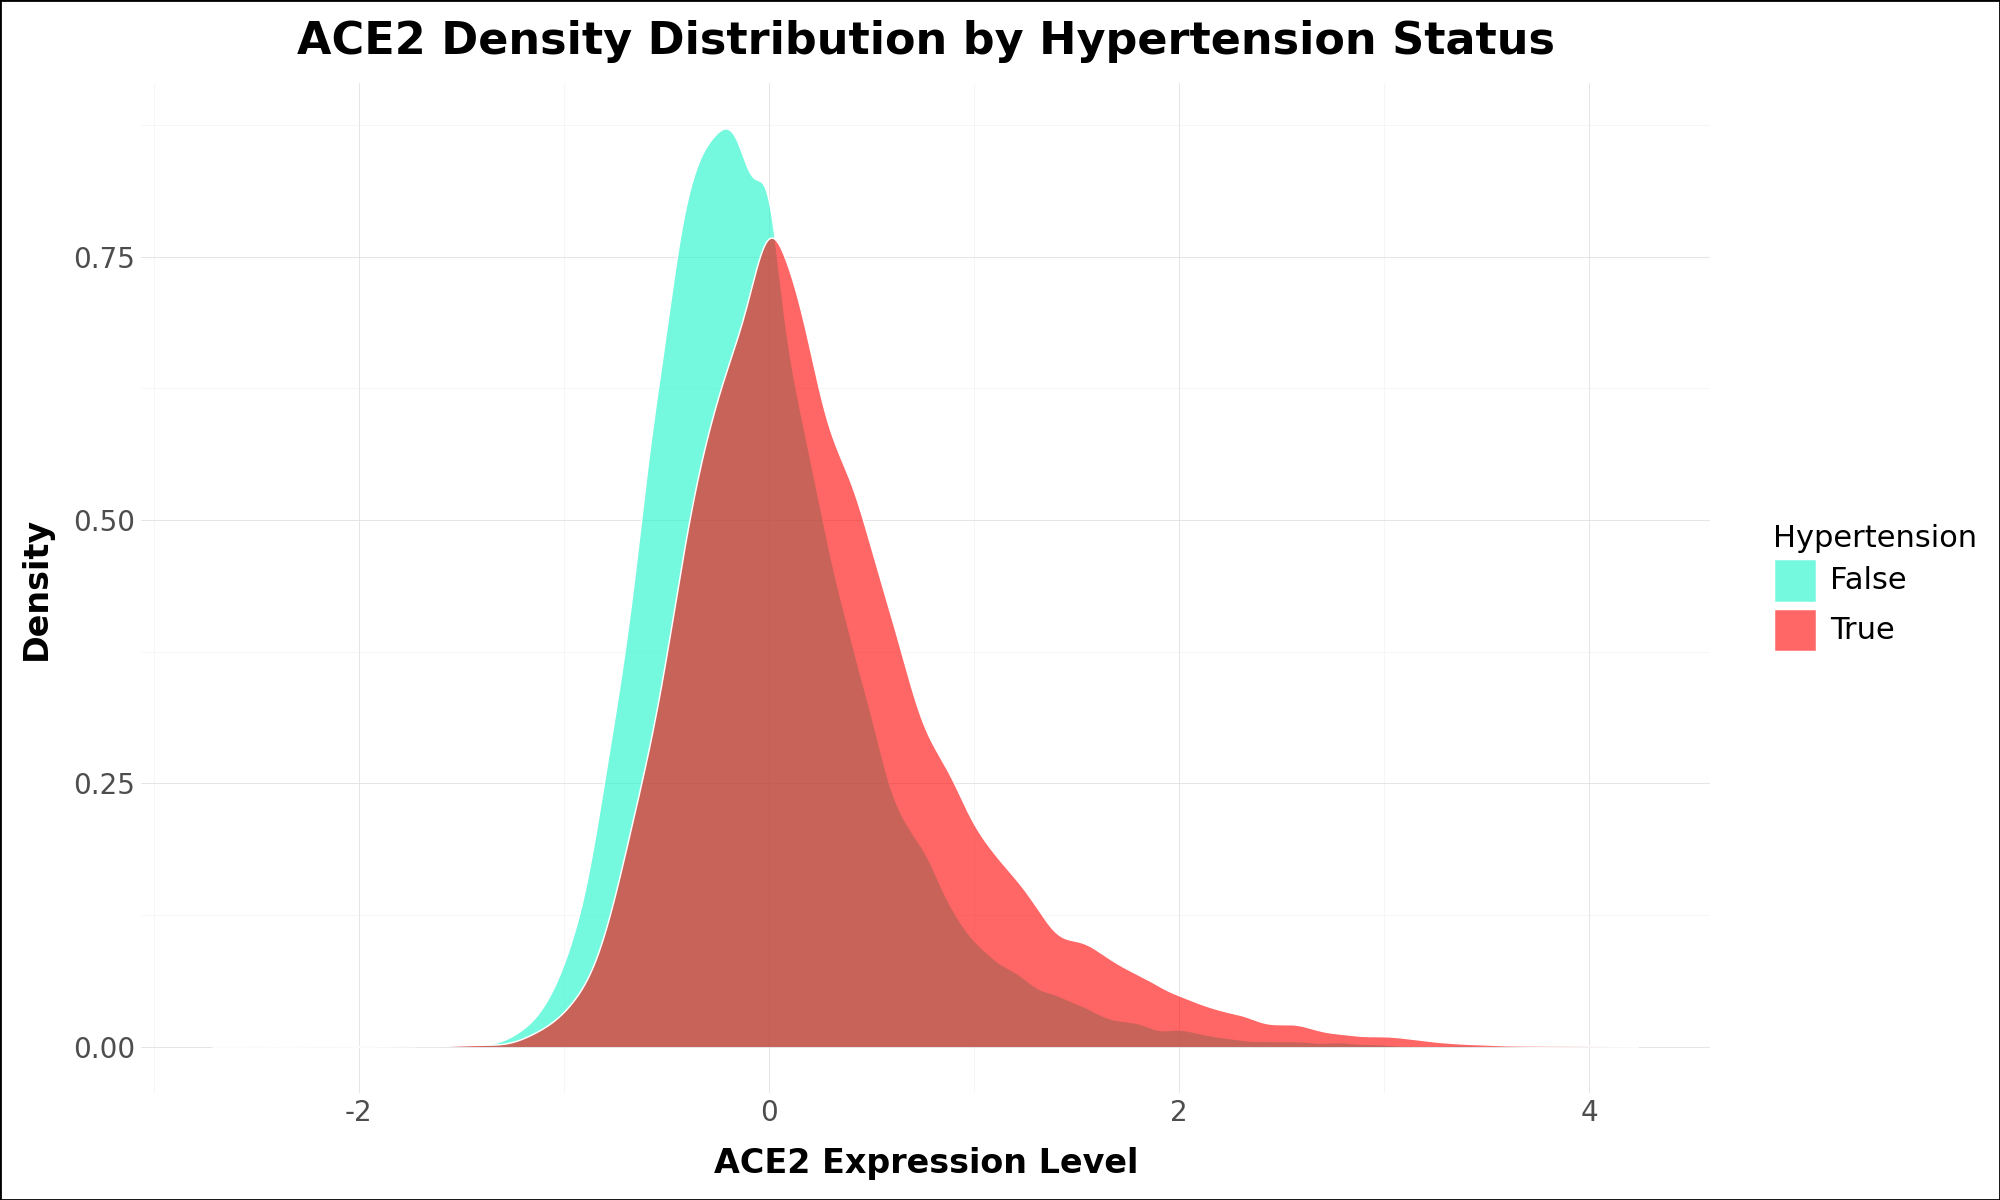

In [125]:
ace_pht_df = df.select('eid', 'ace2', 'hpt')
ace_pht_pd_df = ace_pht_df.collect()

from plotnine import (
    ggplot,
    aes,
    geom_density,
    labs,
    theme_minimal,
    theme,
    element_text,
    element_rect,
    element_line,
    scale_fill_manual,
    guides,
)

custom_colors = {False: "#18F6CA", True: "#FF0000"}

base_plot = (
    ggplot(ace_pht_pd_df, aes(x="ace2", fill="hpt"))
    + geom_density(alpha=0.6, color="white", size=0.3)
    + labs(
        title="ACE2 Density Distribution by Hypertension Status",
        x="ACE2 Expression Level",
        y="Density",
        fill="Hypertension",
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        text=element_text(family="DejaVu Sans", size=11),
        plot_title=element_text(size=16, weight="bold", ha="center"),
        axis_title=element_text(size=12, weight="bold"),
        axis_text=element_text(size=10),
        panel_grid_major=element_line(color="#E0E0E0", size=0.3),
        panel_grid_minor=element_line(color="#F0F0F0", size=0.2),
        legend_position="right",
        legend_key=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color=None),
        panel_background=element_rect(fill="white", color="#E0E0E0"),
    )
    + scale_fill_manual(values=custom_colors)
    + guides(fill="legend")
)


base_plot

In [170]:
# Prepare data
fields = [
    "a1bg",
    "sex",
    "age",
    "bmi",
    "smoking_current",
    "smoking_past",
    "smoking_pack_years",
    "hpt"
]
clean_df = df.select(fields).drop_nans().drop_nulls()


## 蛋白质组Logistic回归

In [171]:

from unittest import result

import statsmodels.api as sm

rename_map = {
    "participant.p131286": "htn_date",
    "participant.p31": "sex",
    "participant.p21003_i0": "age",
    "participant.p21001_i0": "bmi",
    "participant.p1239_i0": "smoking_current",
    "participant.p1249_i0": "smoking_past",
    "participant.p20117_i0": "smoking_pack_years",
    "participant.p6138_i0": "education",
    "participant.p738_i0": "income",
    "participant.p22189": "townsend_di",
    "participant.p54_i0": "assessment_centre",
    "participant.p4080_i0_a0": "systolic_bp_1",
    "participant.p4079_i0_a0": "diastolic_bp_1",
    "participant.p4080_i0_a1": "systolic_bp_2",
    "participant.p4079_i0_a1": "diastolic_bp_2",
    "participant.p2966_i0": "age_htn_diagnosed",
    "olink_instance_0.eid": "olink_eid",
}



X = (
    clean_df.select(
        [
            "a1bg",
            "sex",
            "age",
            "bmi",
            "smoking_current",
            "smoking_past",
            "smoking_pack_years"
        ]
    )
    .collect()
    .to_numpy()
)


X = sm.add_constant(X)

y = clean_df.select("hpt").collect().to_numpy()

# Training
model = sm.Logit(y, X)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.594436
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                41042
Model:                          Logit   Df Residuals:                    41034
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.1297
Time:                        15:41:38   Log-Likelihood:                -24397.
converged:                       True   LL-Null:                       -28032.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.9902      0.129    -61.981      0.000      -8.243      -7.737
x1             0.5974      0.062      9.659      0.000       0.476       0.719
x2             0.4684      0.023     20.133      0.000       0.423       0.514
x3             0.0791      0.001     54.328      0.000       0.076       0.082
x4             0.1210      0.002     48.433      0.000       0.116       0.126
x5            -0.0220      0.032     -0.690      0.490      -0.084       0.040
x6            -0.0524      0.009     -6.139      0.000      -0.069      -0.036
x7            -0.1385      0.022     -6.188      0.000      -0.182      -0.095
==============================================================================
"""

In [151]:
result.pvalues

array([0.00000000e+000, 2.42319237e-026, 2.89658837e-110, 0.00000000e+000,
       0.00000000e+000])

In [153]:
a1bg_beta = result.params[1]

In [154]:
from numpy import exp


exp(a1bg_beta)

np.float64(1.8716506394075412)